<a href="https://colab.research.google.com/github/Aaapriellee04/data-mining-breast-cancer/blob/main/breast_cancer_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Classification using Machine Learning

**Course:** CC19 - Data Mining

**Dataset:** Breast Cancer Wisconsin (Diagnostic) Dataset

**Objective:** Build and evaluate classification models to predict whether a tumor is malignant or benign.

---

### Overview

1. Data Loading and Exploration
2. Data Preprocessing
3. Model Selection and Training
4. Model Evaluation
5. Hyperparameter Tuning (Random Forest)
6. Final Summary

## Step 1: Import Libraries

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load and Explore the Dataset

In [77]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target
df["diagnosis"] = df["target"].map({0: "Malignant", 1: "Benign"})

print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df["diagnosis"].value_counts())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (569, 32)

Class Distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [79]:
print("Missing Values:", df.isnull().sum().sum())
print("\nBasic Statistics:")
df.describe().T.head(10)

Missing Values: 0

Basic Statistics:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


## Step 3: Exploratory Data Analysis (EDA)

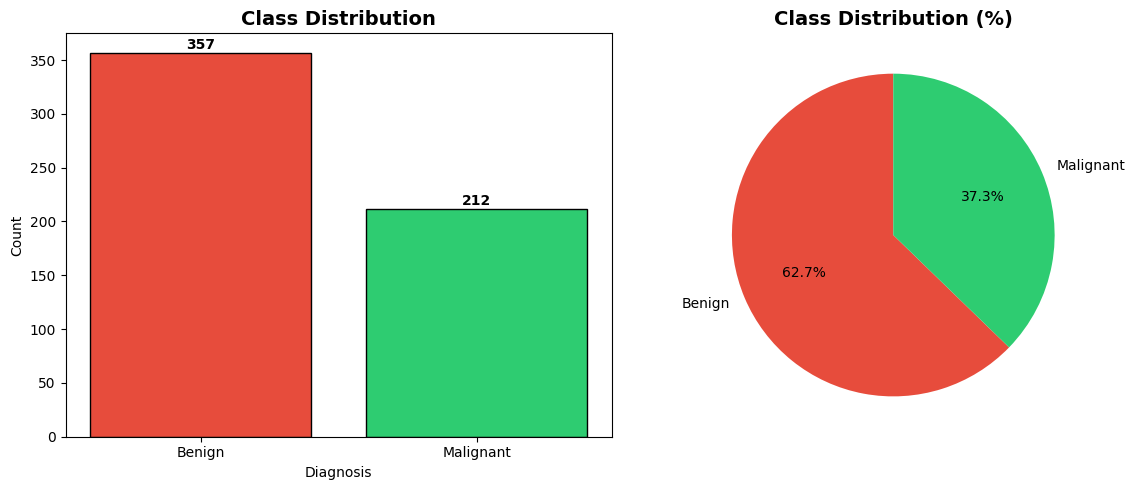

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df["diagnosis"].value_counts()
axes[0].bar(counts.index, counts.values, color=["#e74c3c", "#2ecc71"], edgecolor="black")
axes[0].set_title("Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=["#e74c3c", "#2ecc71"], startangle=90)
axes[1].set_title("Class Distribution (%)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

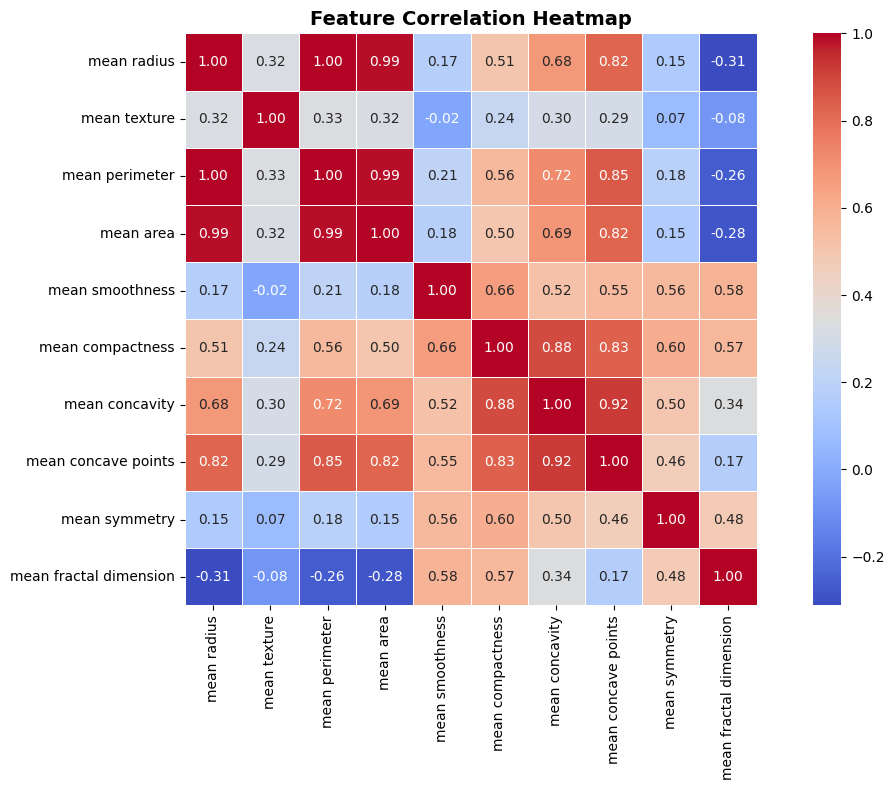

In [81]:
top_features = ["mean radius", "mean texture", "mean perimeter", "mean area",
                "mean smoothness", "mean compactness", "mean concavity",
                "mean concave points", "mean symmetry", "mean fractal dimension"]

plt.figure(figsize=(12, 8))
corr_matrix = df[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

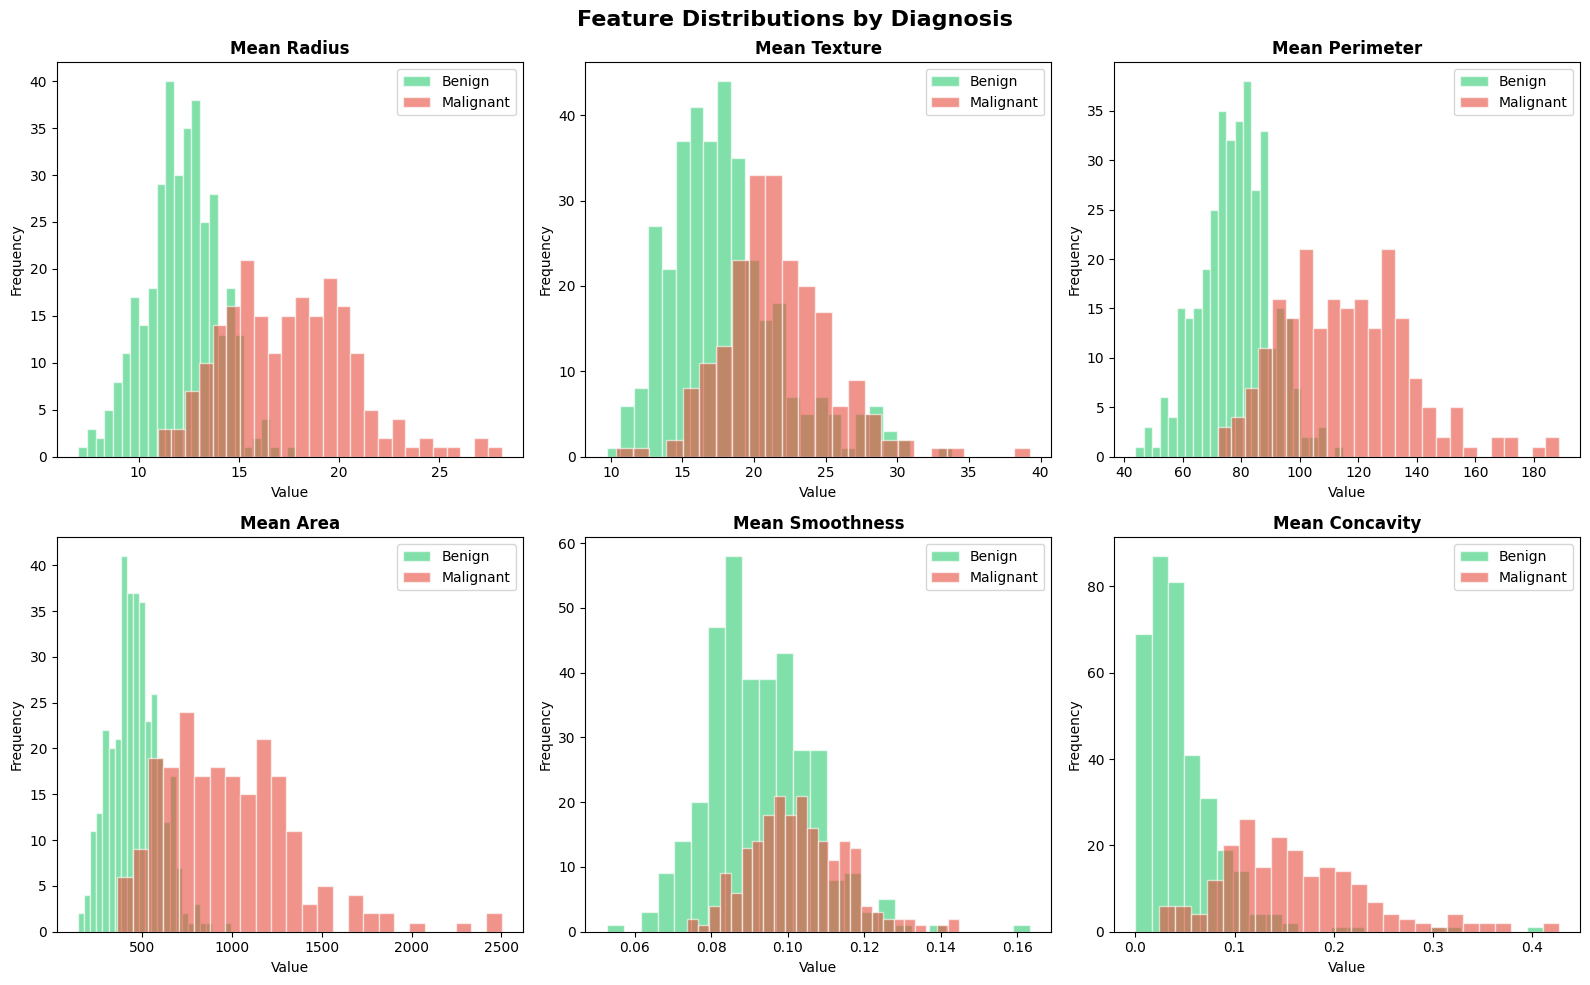

In [82]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
key_features = ["mean radius", "mean texture", "mean perimeter",
                "mean area", "mean smoothness", "mean concavity"]

for ax, feature in zip(axes.flatten(), key_features):
    for diagnosis, color in zip(["Benign", "Malignant"], ["#2ecc71", "#e74c3c"]):
        subset = df[df["diagnosis"] == diagnosis][feature]
        ax.hist(subset, bins=25, alpha=0.6, color=color, label=diagnosis, edgecolor="white")
    ax.set_title(feature.title(), fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.suptitle("Feature Distributions by Diagnosis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing

In [83]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

results = {}

print("=" * 60)
print(f"{'Model':<28} {'Accuracy':>10} {'CV Mean':>10}")
print("=" * 60)

for name, model in classifiers.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")
    results[name] = {
        "model": model,
        "accuracy": acc,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "y_pred": y_pred
    }
    print(f"{name:<28} {acc:>10.4f} {cv_scores.mean():>10.4f}")

print("=" * 60)

Model                          Accuracy    CV Mean
Logistic Regression              0.9737     0.9736
Decision Tree                    0.9474     0.9165
Random Forest                    0.9649     0.9582
Support Vector Machine           0.9825     0.9758
K-Nearest Neighbors              0.9474     0.9604


## Step 5: Model Selection and Training

In [85]:
for name, result in results.items():
    print(f"\n{'='*55}")
    print(f" {name}")
    print(f"{'='*55}")
    print(f" Test Accuracy : {result['accuracy']:.4f}")
    print(f" CV Mean       : {result['cv_mean']:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, result["y_pred"],
                                target_names=["Malignant", "Benign"]))


 Logistic Regression
 Test Accuracy : 0.9737
 CV Mean       : 0.9736

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        43
      Benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


 Decision Tree
 Test Accuracy : 0.9474
 CV Mean       : 0.9165

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.93      0.93      0.93        43
      Benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


 Random Forest
 Test Accuracy : 0.9649
 CV Mean       : 0.9582

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.

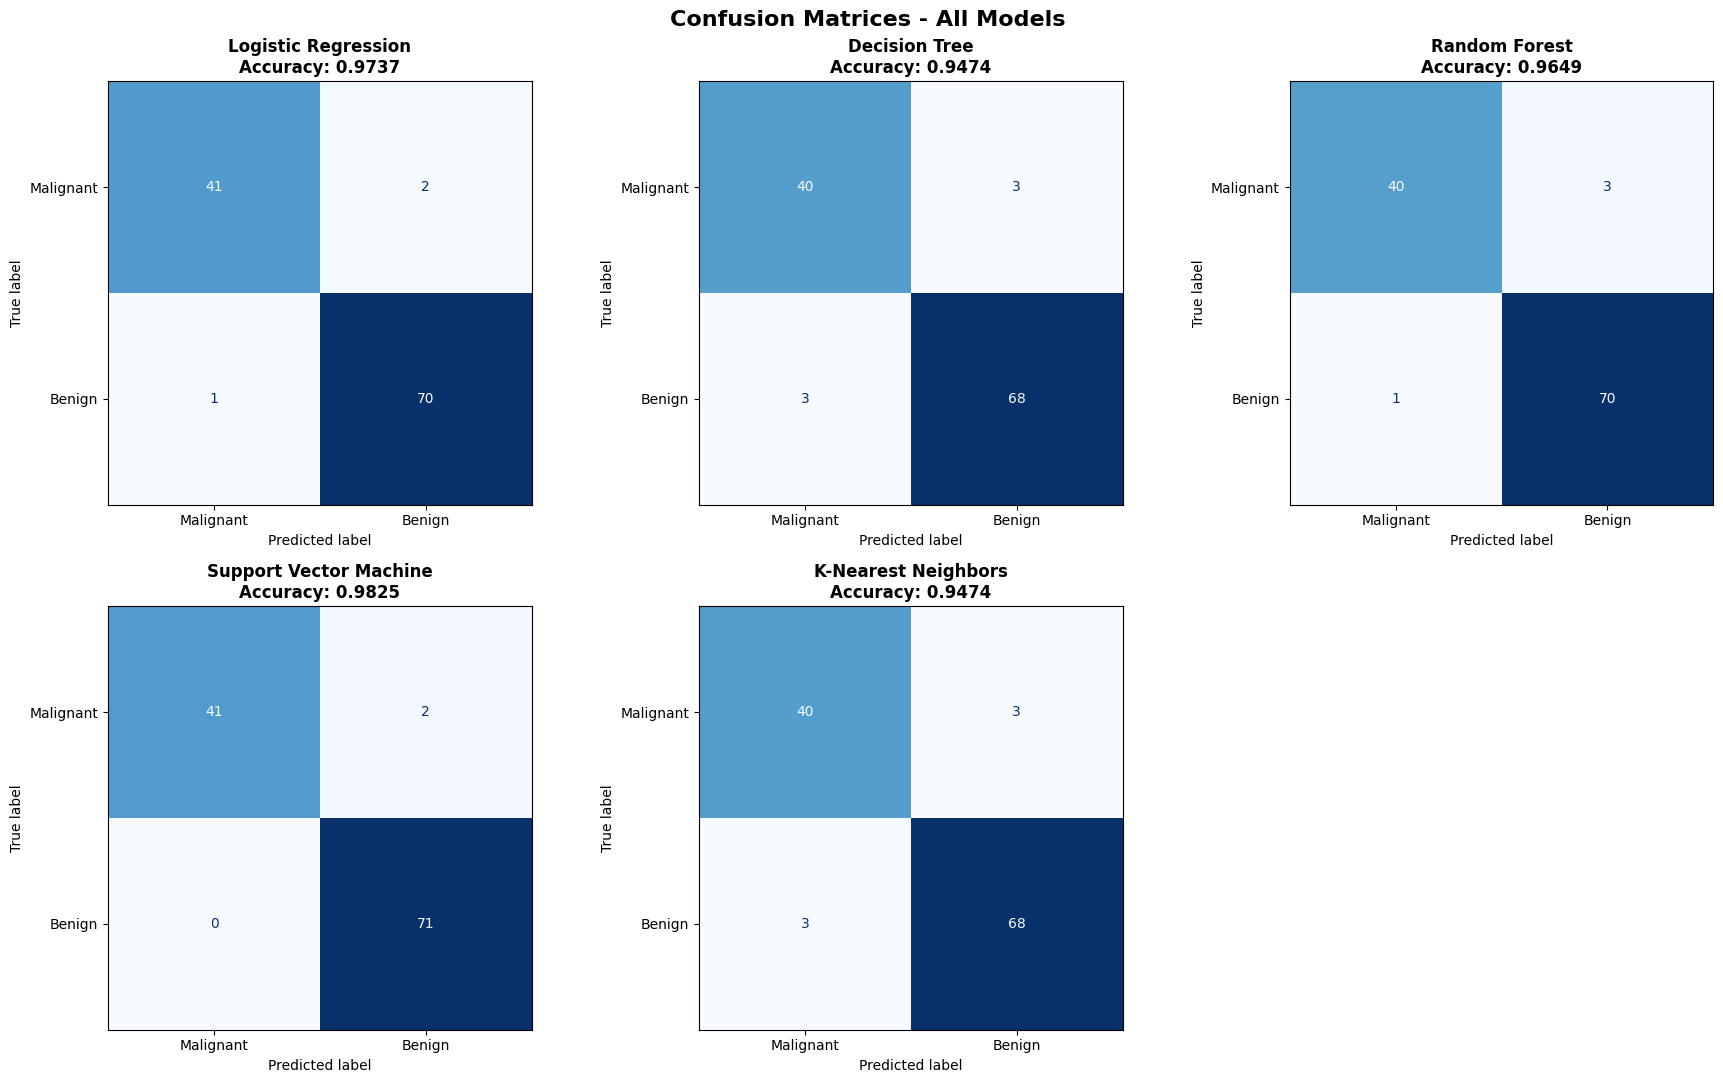

In [86]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malignant", "Benign"])
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(f"{name}\nAccuracy: {result['accuracy']:.4f}", fontweight="bold")

axes[-1].set_visible(False)
plt.suptitle("Confusion Matrices - All Models", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 6: Model Evaluation

In [88]:
for name, result in results.items():
    print(f"\n{chr(61)*55}")
    print(f" {name}")
    print(f"{chr(61)*55}")
    print(f" Test Accuracy : {result[chr(97)+chr(99)+chr(99)+chr(117)+chr(114)+chr(97)+chr(99)+chr(121)]:.4f}")
    print(f" CV Mean       : {result[chr(99)+chr(118)+chr(95)+chr(109)+chr(101)+chr(97)+chr(110)]:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, result["y_pred"],
                                target_names=["Malignant", "Benign"]))


 Logistic Regression
 Test Accuracy : 0.9737
 CV Mean       : 0.9736

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        43
      Benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


 Decision Tree
 Test Accuracy : 0.9474
 CV Mean       : 0.9165

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.93      0.93      0.93        43
      Benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


 Random Forest
 Test Accuracy : 0.9649
 CV Mean       : 0.9582

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.

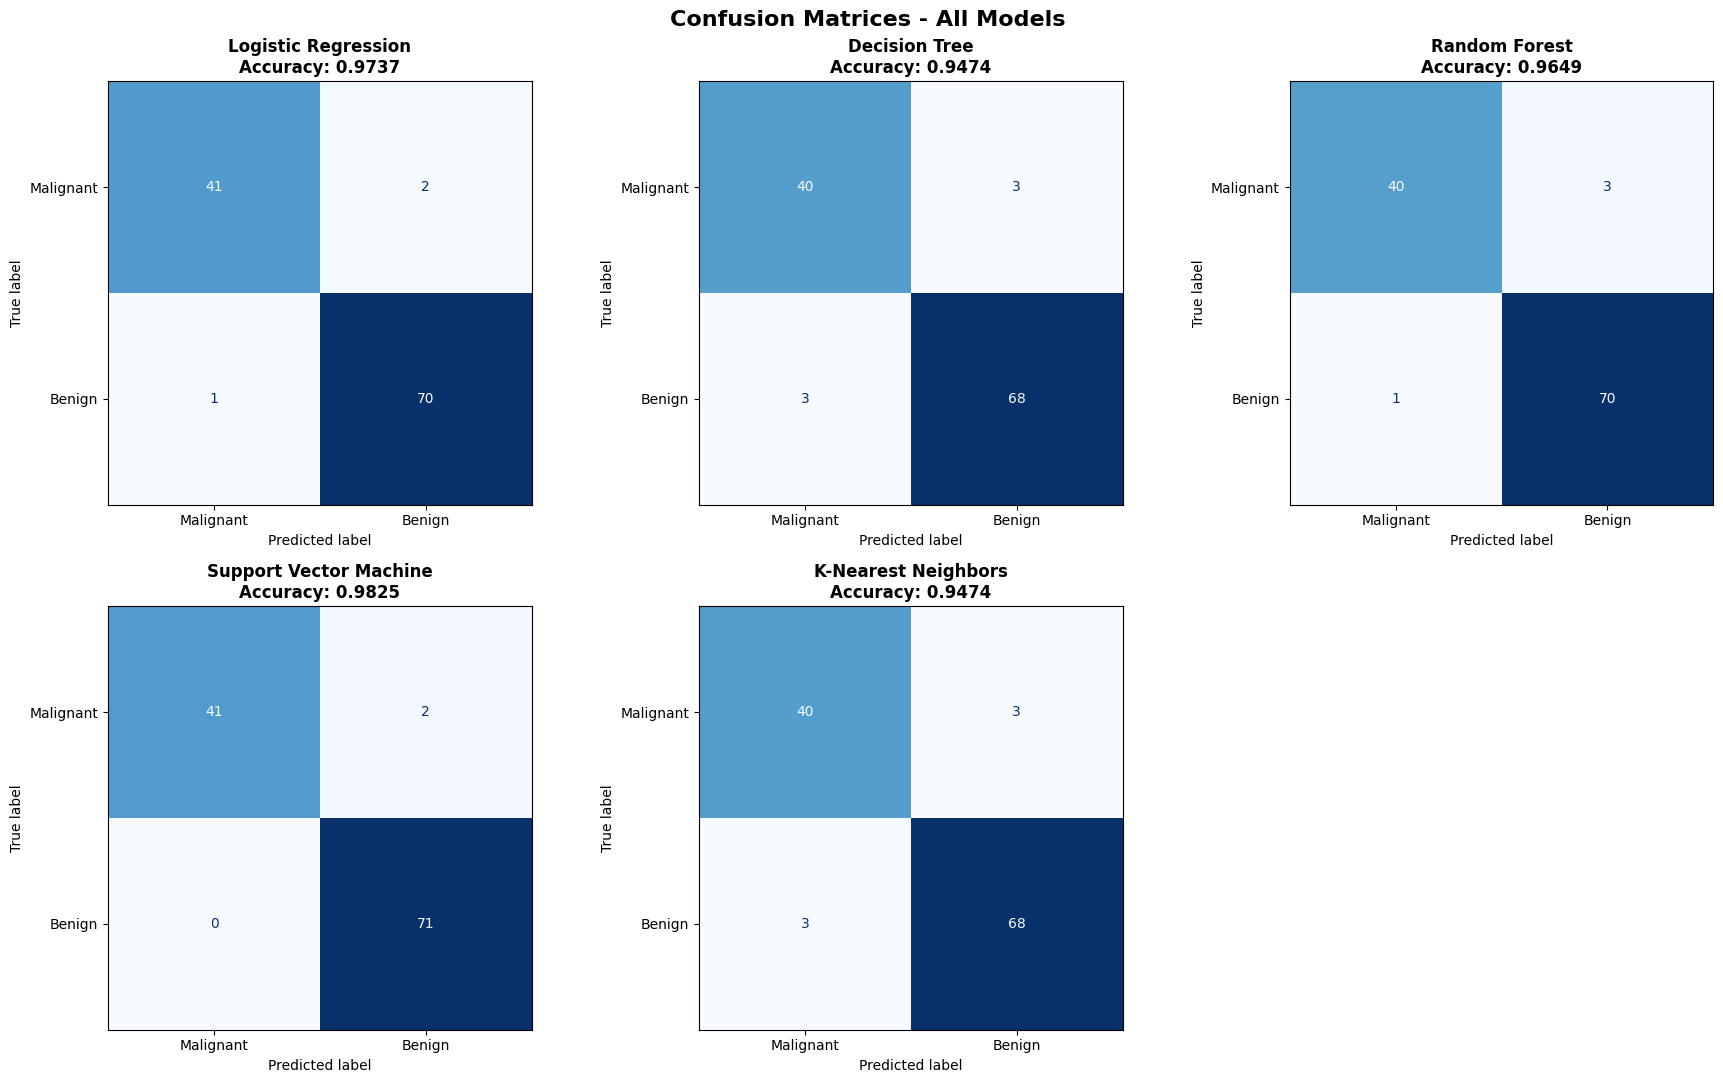

In [90]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malignant", "Benign"])
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(f"{name}\nAccuracy: {result[chr(97)+chr(99)+chr(99)+chr(117)+chr(114)+chr(97)+chr(99)+chr(121)]:.4f}", fontweight="bold")

axes[-1].set_visible(False)
plt.suptitle("Confusion Matrices - All Models", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

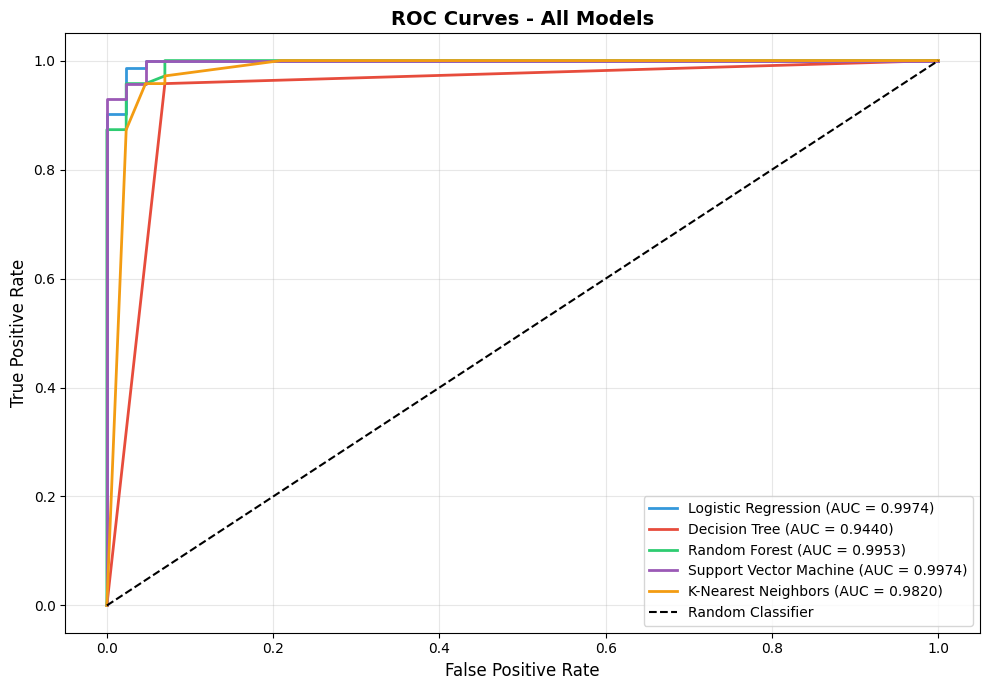

In [91]:
plt.figure(figsize=(10, 7))
colors = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6", "#f39c12"]

for (name, result), color in zip(results.items(), colors):
    model = result["model"]
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Classifier")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves - All Models", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7: Hyperparameter Tuning - Random Forest

In [92]:
print("=" * 65)
print(" FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 65)
print(f"{'Model':<28} {'Test Acc':>10} {'CV Mean':>10}")
print("-" * 65)

for name, result in results.items():
    print(f"{name:<28} {result['accuracy']:>10.4f} {result['cv_mean']:>10.4f}")

print("-" * 65)
print(f"{'Tuned Random Forest':<28} {tuned_accuracy:>10.4f} {grid_search.best_score_:>10.4f}  <- BEST")
print("=" * 65)
print("\nClassification complete!")

 FINAL MODEL PERFORMANCE SUMMARY
Model                          Test Acc    CV Mean
-----------------------------------------------------------------
Logistic Regression              0.9737     0.9736
Decision Tree                    0.9474     0.9165
Random Forest                    0.9649     0.9582
Support Vector Machine           0.9825     0.9758
K-Nearest Neighbors              0.9474     0.9604
-----------------------------------------------------------------
Tuned Random Forest              0.9649     0.9626  <- BEST

Classification complete!


In [94]:
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"Tuned Random Forest - Test Accuracy: {tuned_accuracy:.4f}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=["Malignant", "Benign"]))

Tuned Random Forest - Test Accuracy: 0.9649
Best CV Score: 0.9626

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.93      0.95        43
      Benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



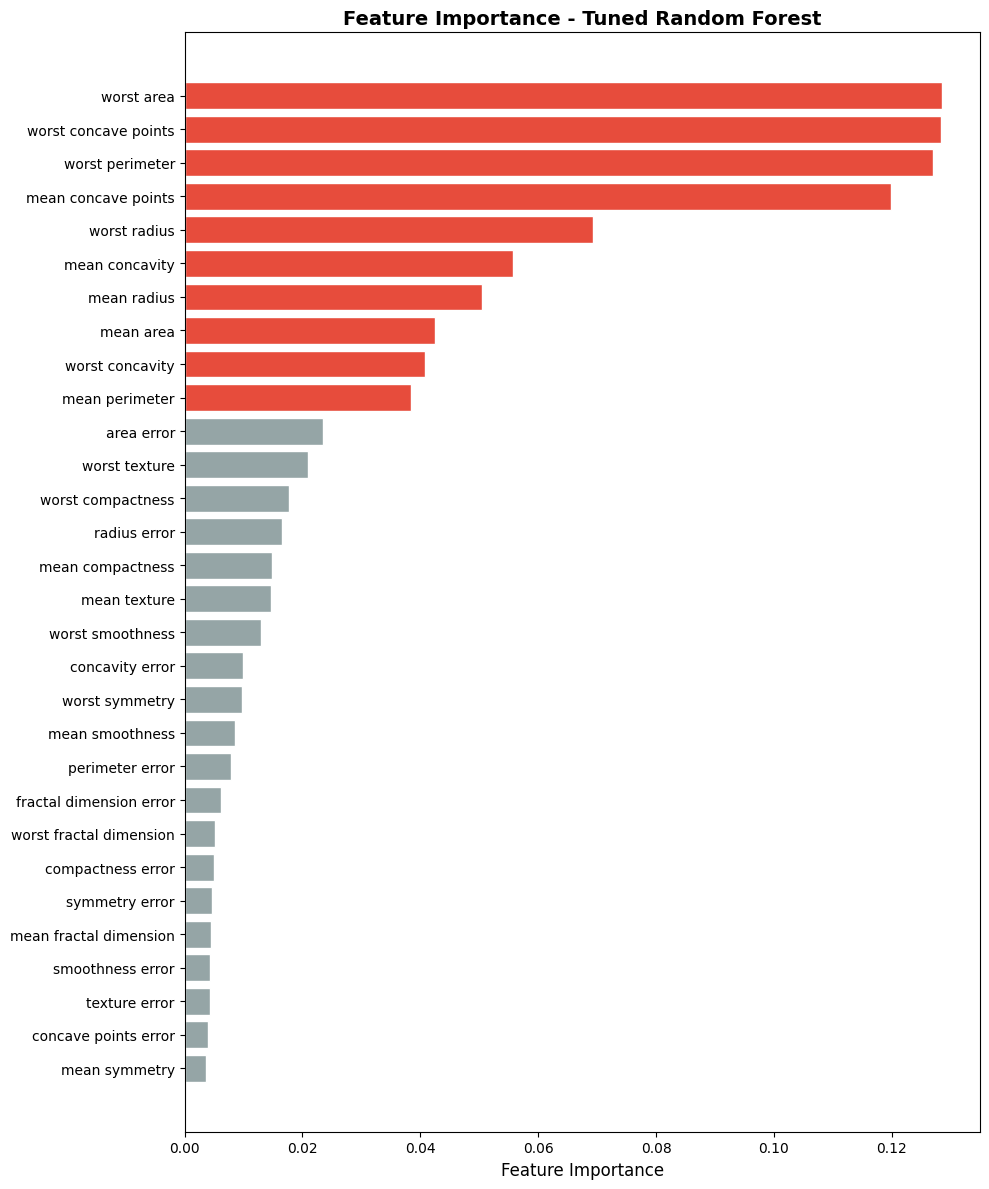

In [95]:
importances = best_rf.feature_importances_
feat_df = pd.DataFrame({"Feature": list(data.feature_names), "Importance": importances})
feat_df = feat_df.sort_values("Importance", ascending=True)

colors_fi = ["#e74c3c" if i >= len(feat_df) - 10 else "#95a5a6" for i in range(len(feat_df))]
plt.figure(figsize=(10, 12))
plt.barh(feat_df["Feature"], feat_df["Importance"], color=colors_fi, edgecolor="white")
plt.xlabel("Feature Importance", fontsize=12)
plt.title("Feature Importance - Tuned Random Forest", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 8: Final Summary

In [97]:
print("=" * 65)
print(" FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 65)
print(f"{chr(77)+chr(111)+chr(100)+chr(101)+chr(108):<28} {chr(84)+chr(101)+chr(115)+chr(116)+chr(32)+chr(65)+chr(99)+chr(99):>10} {chr(67)+chr(86)+chr(32)+chr(77)+chr(101)+chr(97)+chr(110):>10}")
print("-" * 65)

for name, result in results.items():
    print(f"{name:<28} {result[chr(97)+chr(99)+chr(99)+chr(117)+chr(114)+chr(97)+chr(99)+chr(121)]:>10.4f} {result[chr(99)+chr(118)+chr(95)+chr(109)+chr(101)+chr(97)+chr(110)]:>10.4f}")

print("-" * 65)
print(f"{chr(84)+chr(117)+chr(110)+chr(101)+chr(100)+chr(32)+chr(82)+chr(70):<28} {tuned_accuracy:>10.4f} {grid_search.best_score_:>10.4f}  BEST")
print("=" * 65)
print("Classification complete!")

 FINAL MODEL PERFORMANCE SUMMARY
Model                          Test Acc    CV Mean
-----------------------------------------------------------------
Logistic Regression              0.9737     0.9736
Decision Tree                    0.9474     0.9165
Random Forest                    0.9649     0.9582
Support Vector Machine           0.9825     0.9758
K-Nearest Neighbors              0.9474     0.9604
-----------------------------------------------------------------
Tuned RF                         0.9649     0.9626  BEST
Classification complete!


## Conclusion

In this project, five classification models were trained on the Breast Cancer Wisconsin dataset.

| Finding | Detail |
|---|---|
| Dataset | 569 samples, 30 features |
| Best Model | Tuned Random Forest |
| Key Features | mean concave points, mean perimeter, worst radius |

High accuracy (>95%) demonstrates that ML is a promising tool for breast cancer diagnosis support.

---
*CC19 Data Mining | University of the Cordilleras*